In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [27]:
df = pd.read_csv("sample (1).csv")

print("Shape:", df.shape)
df.head()

Shape: (93, 7)


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,119237,105834,True,Wed Oct 11 06:55:44 +0000 2017,@AppleSupport causing the reply to be disregar...,119236,NaN
1,119238,ChaseSupport,False,Wed Oct 11 13:25:49 +0000 2017,@105835 Your business means a lot to us. Pleas...,NaN,119239.0
2,119239,105835,True,Wed Oct 11 13:00:09 +0000 2017,@76328 I really hope you all change but I'm su...,119238,NaN
3,119240,VirginTrains,False,Tue Oct 10 15:16:08 +0000 2017,@105836 LiveChat is online at the moment - htt...,119241,119242.0
4,119241,105836,True,Tue Oct 10 15:17:21 +0000 2017,@VirginTrains see attached error message. I've...,119243,119240.0


In [28]:
# First column = text
# Second column = category

text_col = df.columns[0]
target_col = df.columns[1]

print("Text Column:", text_col)
print("Target Column:", target_col)

Text Column: tweet_id
Target Column: author_id


In [29]:
df = df[[text_col, target_col]].copy()
df.dropna(inplace=True)

df.head()

,tweet_id,author_id
0,119237,105834
1,119238,ChaseSupport
2,119239,105835
3,119240,VirginTrains
4,119241,105836


In [22]:
df = df[[text_col, target_col]].copy()
df.dropna(inplace=True)

df.head()

,tweet_id,author_id
0,119237,105834
1,119238,ChaseSupport
2,119239,105835
3,119240,VirginTrains
4,119241,105836


In [32]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    
    # keep words only
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    words = text.split()
    
    # IMPORTANT: keep words even if stopwords removed everything
    if len(words) == 0:
        return "empty"
    
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    # if all removed → keep original words
    if len(words) == 0:
        words = text.split()
    
    return " ".join(words)

df['clean_text'] = df[text_col].apply(clean_text)

In [33]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'])
y = df[target_col]

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [38]:
model = LogisticRegression(max_iter=200, class_weight='balanced')
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [36]:
y_pred = model.predict(X_test)

In [39]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.21052631578947367
                 precision    recall  f1-score   support

         105834       0.00      0.00      0.00         1
         105836       0.00      0.00      0.00         1
         105838       0.00      0.00      0.00         1
         105840       0.00      0.00      0.00         2
         105842       0.00      0.00      0.00         1
         105843       0.00      0.00      0.00         1
         105846       0.00      0.00      0.00         1
         105847       0.00      0.00      0.00         1
         105854       0.00      0.00      0.00         1
         105855       0.00      0.00      0.00         1
   AppleSupport       0.21      1.00      0.35         4
British_Airways       0.00      0.00      0.00         1
   SouthwestAir       0.00      0.00      0.00         1
          Tesco       0.00      0.00      0.00         1
   comcastcares       0.00      0.00      0.00         1

       accuracy                           0.21        19

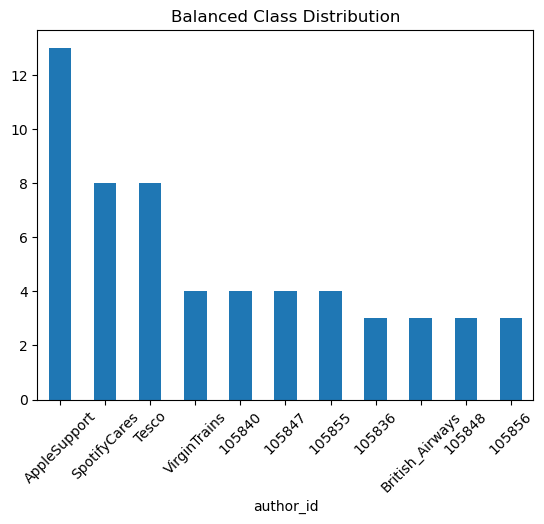

In [44]:
plt.figure()
df[target_col].value_counts().plot(kind='bar')
plt.title("Balanced Class Distribution")
plt.xticks(rotation=45)
plt.show()

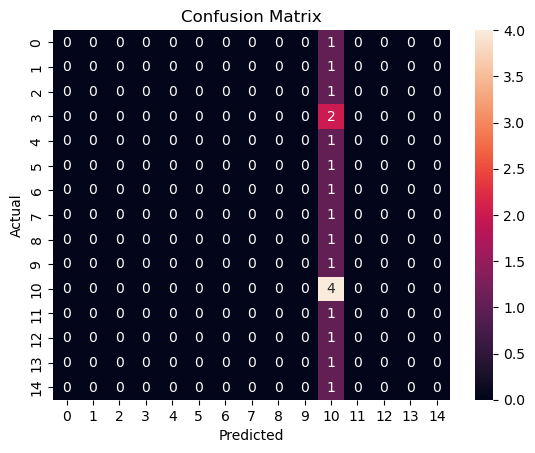

In [47]:
def assign_priority(text):
    text = str(text).lower()   # 🔥 FIX HERE
    
    if "urgent" in text or "refund" in text or "not working" in text:
        return "High"
    elif "delay" in text or "slow" in text:
        return "Medium"
    else:
        return "Low"
df['priority'] = df[text_col].apply(assign_priority)

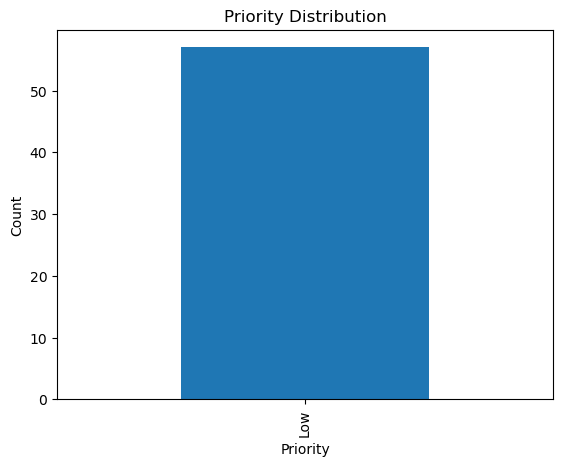

In [48]:
plt.figure()
df['priority'].value_counts().plot(kind='bar')
plt.title("Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Count")
plt.show()

In [49]:
sample_text = ["I want refund immediately, product not working"]

sample_clean = [clean_text(t) for t in sample_text]
sample_vec = vectorizer.transform(sample_clean)

prediction = model.predict(sample_vec)

print("Predicted Category:", prediction[0])
print("Priority:", assign_priority(sample_text[0]))

Predicted Category: 105676
Priority: High
